# Projeto Final – INF 791 Redes Complexas
**Aluna:** Aymê Faustino | **Matrícula:** 4704

**Título:** Toxicidade em Redes de Grupos Políticos do WhatsApp

**Universidade Federal de Viçosa – 1º Semestre de 2026**

---

## Questões de Pesquisa
- **Q1:** Grupos mais centrais na rede são também os mais tóxicos?
- **Q2:** A toxicidade está concentrada em poucos grupos ou distribuída de forma uniforme?
- **Q3:** Existem comunidades de grupos com padrões de toxicidade distintos?
- **Q4:** Grupos com toxicidade similar tendem a se conectar mais entre si? (homofilia)

---

## Estrutura do Notebook

### Parte 1 — Rede Completa (2020–2024)
Caracterização estrutural geral da rede. Aproveita os resultados do trabalho intermediário.

### Parte 2 — Subgrafo 2022
Análise de toxicidade e resposta às Q1–Q4. Restrita a 2022 por ser o ano de maior
volume de mensagens (5,6M) e de maior relevância política (eleições presidenciais).
As métricas de centralidade são recalculadas sobre o subgrafo de 2022.

---
## 0. Instalações e Imports

In [13]:
import json
import os
import re
import random
import pickle
from collections import defaultdict, Counter
from itertools import combinations

import pandas as pd
import numpy as np
import networkx as nx
from scipy import stats as scipy_stats

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.cm import ScalarMappable
import community as community_louvain
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Imports OK!')

Imports OK!


In [3]:
# ── Caminhos e parâmetros ─────────────────────────────────────────────────────
ARQUIVO_LIMPO        = 'dataset_limpo.jsonl'
CACHE_REDE_COMPLETA  = 'cache_rede_completa.pkl'
CACHE_REDE_2022      = 'cache_rede_2022.pkl'
CACHE_TOXICIDADE     = 'cache_toxicidade_2022.pkl'

ANO_ANALISE          = '2022'
MAX_MSGS_POR_GRUPO   = 500   # mensagens amostradas por grupo para o Detoxify
MIN_MSGS_POR_GRUPO   = 10    # grupos com menos mensagens são descartados
BATCH_SIZE           = 64

print('Configuração OK!')

Configuração OK!


### Sobre o uso de cache

Estamos usando a técnica de salvar o grafo em cache para que não seja necessário
reprocessar etapas que demoram muito toda vez que o notebook for executado novamente.
As etapas que usam cache são a construção da rede completa, a construção do subgrafo
de 2022 e os escores de toxicidade. O cache dos escores ainda salva parcialmente a cada 100 grupos, então mesmo que o notebook trave no meio, o progresso não é perdido.

---
# PARTE 1 — Rede Completa (2020–2024)

Carregamos o dataset completo para construir o grafo de grupos e calcular
as métricas estruturais gerais. Esses resultados complementam e expandem
os do trabalho intermediário.

In [4]:
if os.path.exists(CACHE_REDE_COMPLETA):
    print('Carregando rede completa do cache...')
    with open(CACHE_REDE_COMPLETA, 'rb') as f:
        cache = pickle.load(f)
    G_completo = cache['G']
    grupo_nomes = cache['grupo_nomes']
    print(f'Rede completa: {G_completo.number_of_nodes():,} nós, {G_completo.number_of_edges():,} arestas')
else:
    print('Construindo rede completa (2020–2024)...')
    grupo_usuarios = defaultdict(set)
    grupo_nomes = {}

    with open(ARQUIVO_LIMPO, 'r', encoding='utf-8') as f:
        for linha in tqdm(f, desc='Carregando dataset completo'):
            try:
                msg = json.loads(linha)
                grupo_usuarios[msg['group_id']].add(msg['sender'])
                if msg['group_id'] not in grupo_nomes:
                    grupo_nomes[msg['group_id']] = msg.get('group_name', msg['group_id'])
            except:
                pass

    print(f'Grupos únicos: {len(grupo_usuarios):,}')

    G_completo = nx.Graph()
    grupos = list(grupo_usuarios.keys())
    G_completo.add_nodes_from(grupos)

    for g1, g2 in tqdm(combinations(grupos, 2),total=(len(grupos) * (len(grupos) - 1)) // 2,desc='Arestas'):
        peso = len(grupo_usuarios[g1].intersection(grupo_usuarios[g2]))
        if peso > 0:
            G_completo.add_edge(g1, g2, weight=peso)

    nx.set_node_attributes(G_completo, grupo_nomes, 'name')

    with open(CACHE_REDE_COMPLETA, 'wb') as f:
        pickle.dump({'G': G_completo, 'grupo_nomes': grupo_nomes}, f)

    print(f'Nós: {G_completo.number_of_nodes():,} | Arestas: {G_completo.number_of_edges():,}')

Carregando rede completa do cache...
Rede completa: 2,109 nós, 89,421 arestas


In [5]:
# ── Métricas estruturais da rede completa ─────────────────────────────────────
componentes = list(nx.connected_components(G_completo))
nos_maior_c = max(componentes, key=len)
G_maior_c = G_completo.subgraph(nos_maior_c).copy()

graus_c = [d for _, d in G_completo.degree()]
cc_medio_c = nx.average_clustering(G_completo)
densidade_c = nx.density(G_completo)

print('=== REDE COMPLETA (2020–2024) ===')
print(f'Nós (grupos):           {G_completo.number_of_nodes():,}')
print(f'Arestas:                {G_completo.number_of_edges():,}')
print(f'Densidade:              {densidade_c:.6f}')
print(f'Componentes:            {len(componentes):,}')
print(f'Maior componente:       {len(nos_maior_c):,} nós ({100*len(nos_maior_c)/G_completo.number_of_nodes():.1f}%)')
print(f'Grau médio:             {np.mean(graus_c):.2f}')
print(f'Grau mediano:           {np.median(graus_c):.0f}')
print(f'Grau máximo:            {max(graus_c):,}')
print(f'Clustering médio:       {cc_medio_c:.4f}')

=== REDE COMPLETA (2020–2024) ===
Nós (grupos):           2,109
Arestas:                89,421
Densidade:              0.040227
Componentes:            181
Maior componente:       1,860 nós (88.2%)
Grau médio:             84.80
Grau mediano:           21
Grau máximo:            719
Clustering médio:       0.5568


---
# PARTE 2 — Subgrafo 2022

Restringimos a análise ao ano de 2022 pelos seguintes motivos:
- **Maior volume:** 5,6M de mensagens (41,7% do dataset)
- **Relevância política:** ano das eleições presidenciais brasileiras
- **Viabilidade computacional:** 1.222 grupos permitem rodar o Detoxify em CPU

As métricas de centralidade são **recalculadas sobre o subgrafo de 2022**,
garantindo que as correlações com toxicidade reflitam a estrutura desse período.

Antes usamos uma função apenas para tirar mais algumas mensagens de ruido.

In [6]:
# ── Função de filtragem de ruído ──────────────────────────────────────────────
SAUDACOES = {
    'bom dia', 'boa tarde', 'boa noite', 'boa semana', 'bom fds',
    'obrigado', 'obrigada', 'valeu', 'vlw', 'ok', 'sim', 'nao', 'nao sei',
    'verdade', 'isso', 'exato', 'certeza', 'claro', 'amen', 'amem',
    'parabens', 'feliz aniversario', 'saude', 'jesus', 'deus',
}
PADROES_RUIDO = [
    r'^k+$',
    r'^(ha|he|hi|hu)+$',
    r'^(rs)+$',
    r'^\d+$',
    r'^.{1,10}$',
]

def is_ruido(texto):
    t = texto.strip().lower()
    if t in SAUDACOES:
        return True
    return any(re.fullmatch(p, t) for p in PADROES_RUIDO)

In [7]:
# ── Construir subgrafo de 2022 ────────────────────────────────────────────────
if os.path.exists(CACHE_REDE_2022):
    print('Carregando subgrafo 2022 do cache...')
    with open(CACHE_REDE_2022, 'rb') as f:
        cache2022 = pickle.load(f)
    G_2022 = cache2022['G']
    grupo_msgs_2022 = cache2022['grupo_msgs']
    grupo_nomes_2022 = cache2022['grupo_nomes']
    print(f'Subgrafo 2022: {G_2022.number_of_nodes():,} nós, {G_2022.number_of_edges():,} arestas')
else:
    print('Construindo subgrafo 2022...')
    grupo_usuarios_2022 = defaultdict(set)
    grupo_nomes_2022 = {}
    grupo_msgs_2022 = defaultdict(list)

    with open(ARQUIVO_LIMPO, 'r', encoding='utf-8') as f:
        for linha in tqdm(f, desc='Filtrando 2022'):
            try:
                msg = json.loads(linha)
                if msg.get('date', '')[:4] != ANO_ANALISE:
                    continue
                gid = msg['group_id']
                grupo_usuarios_2022[gid].add(msg['sender'])
                texto = msg['texto']
                if not is_ruido(texto):
                    grupo_msgs_2022[gid].append(texto)
                if gid not in grupo_nomes_2022:
                    grupo_nomes_2022[gid] = msg.get('group_name', gid)
            except:
                pass

    print(f'Grupos em 2022: {len(grupo_usuarios_2022):,}')
    print('Construindo arestas do subgrafo...')

    G_2022 = nx.Graph()
    grupos_2022 = list(grupo_usuarios_2022.keys())
    G_2022.add_nodes_from(grupos_2022)

    for g1, g2 in tqdm(combinations(grupos_2022, 2),total=(len(grupos_2022) * (len(grupos_2022) - 1)) // 2,desc='Arestas 2022'):
        peso = len(grupo_usuarios_2022[g1].intersection(grupo_usuarios_2022[g2]))
        if peso > 0:
            G_2022.add_edge(g1, g2, weight=peso)

    nx.set_node_attributes(G_2022, grupo_nomes_2022, 'name')

    with open(CACHE_REDE_2022, 'wb') as f:
        pickle.dump({
            'G': G_2022,
            'grupo_msgs': dict(grupo_msgs_2022),
            'grupo_nomes': grupo_nomes_2022
        }, f)
    print(f'Nós: {G_2022.number_of_nodes():,} | Arestas: {G_2022.number_of_edges():,}')

Carregando subgrafo 2022 do cache...
Subgrafo 2022: 1,222 nós, 43,376 arestas


In [8]:
componentes_22 = list(nx.connected_components(G_2022))
nos_maior_22 = max(componentes_22, key=len)
G_maior_22 = G_2022.subgraph(nos_maior_22).copy()

graus_22 = [d for _, d in G_2022.degree()]
cc_medio_22 = nx.average_clustering(G_2022)
densidade_22 = nx.density(G_2022)

print('=== SUBGRAFO 2022 ===')
print(f'Nós (grupos):           {G_2022.number_of_nodes():,}')
print(f'Arestas:                {G_2022.number_of_edges():,}')
print(f'Densidade:              {densidade_22:.6f}')
print(f'Componentes:            {len(componentes_22):,}')
print(f'Maior componente:       {len(nos_maior_22):,} nós ({100*len(nos_maior_22)/G_2022.number_of_nodes():.1f}%)')
print(f'Grau médio:             {np.mean(graus_22):.2f}')
print(f'Grau mediano:           {np.median(graus_22):.0f}')
print(f'Grau máximo:            {max(graus_22):,}')
print(f'Clustering médio:       {cc_medio_22:.4f}')

=== SUBGRAFO 2022 ===
Nós (grupos):           1,222
Arestas:                43,376
Densidade:              0.058142
Componentes:            139
Maior componente:       1,053 nós (86.2%)
Grau médio:             70.99
Grau mediano:           26
Grau máximo:            444
Clustering médio:       0.4848


In [ ]:
pesos = [d["weight"] for _, _, d in G_2022.edges(data=True)]

print(pd.Series(pesos).describe())

for p in [50, 70, 80, 90, 95, 99]:
    print(f"P{p}: {np.percentile(pesos, p)}")

Calculando distâncias...


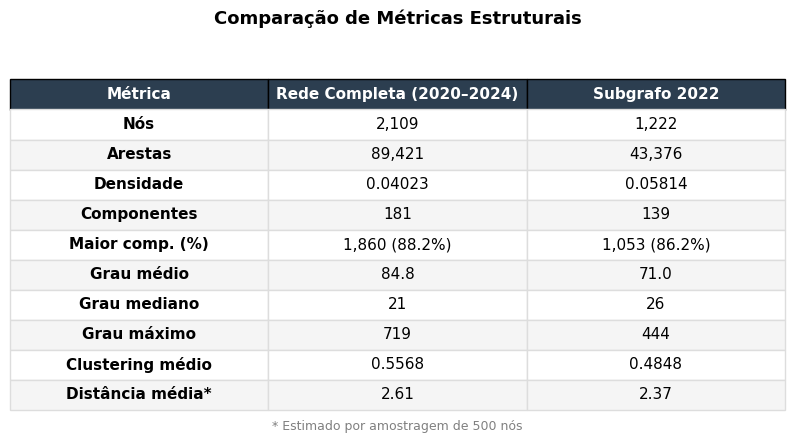

In [ ]:
def dist_media(G, n=500):
    nos = max(nx.connected_components(G), key=len)
    G_m = G.subgraph(nos).copy()
    amostra = random.sample(list(G_m.nodes()), min(n, G_m.number_of_nodes()))
    dists = [v for no in amostra
             for v in nx.single_source_shortest_path_length(G_m, no).values() if v > 0]
    return np.mean(dists)

print('Calculando distâncias...')
d_c, d_22 = dist_media(G_completo), dist_media(G_2022)

graus_c = [d for _, d in G_completo.degree()]
graus_22 = [d for _, d in G_2022.degree()]

dados = [
    ('Nós',              f"{G_completo.number_of_nodes():,}",       f"{G_2022.number_of_nodes():,}"),
    ('Arestas',          f"{G_completo.number_of_edges():,}",       f"{G_2022.number_of_edges():,}"),
    ('Densidade',        f"{nx.density(G_completo):.5f}",           f"{nx.density(G_2022):.5f}"),
    ('Componentes',      f"{len(componentes):,}",                   f"{len(componentes_22):,}"),
    ('Maior comp. (%)',  f"{len(nos_maior_c):,} ({100*len(nos_maior_c)/G_completo.number_of_nodes():.1f}%)", f"{len(nos_maior_22):,} ({100*len(nos_maior_22)/G_2022.number_of_nodes():.1f}%)"),
    ('Grau médio',       f"{np.mean(graus_c):.1f}",                 f"{np.mean(graus_22):.1f}"),
    ('Grau mediano',     f"{np.median(graus_c):.0f}",               f"{np.median(graus_22):.0f}"),
    ('Grau máximo',      f"{max(graus_c):,}",                       f"{max(graus_22):,}"),
    ('Clustering médio', f"{cc_medio_c:.4f}",                       f"{cc_medio_22:.4f}"),
    ('Distância média*', f"{d_c:.2f}",                              f"{d_22:.2f}"),
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')
t = ax.table(cellText=[[m, v1, v2] for m, v1, v2 in dados],colLabels=['Métrica', 'Rede Completa (2020–2024)', 'Subgrafo 2022'],
             cellLoc='center', loc='center')
t.auto_set_font_size(False)
t.set_fontsize(11)
t.scale(1, 1.8)

for col in range(3):
    t[0, col].set_facecolor('#2c3e50')
    t[0, col].set_text_props(color='white', fontweight='bold')
for row in range(1, len(dados) + 1):
    cor = '#f5f5f5' if row % 2 == 0 else 'white'
    for col in range(3):
        t[row, col].set_facecolor(cor)
        t[row, col].set_edgecolor('#dddddd')
    t[row, 0].set_text_props(fontweight='bold')

ax.set_title('Comparação de Métricas Estruturais', fontsize=13, fontweight='bold', pad=20)
ax.text(0.5, 0.02, '* Estimado por amostragem de 500 nós', transform=ax.transAxes,fontsize=9, color='gray', ha='center')
plt.savefig('tabela_comparativa_redes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2.1 Detecção de Toxicidade com Detoxify (subgrafo 2022)

Usamos o modelo **`multilingual`** do Detoxify (XLM-RoBERTa), adequado para português.
Para cada grupo, amostramos até 200 mensagens aleatórias e calculamos a média dos escores.
Os resultados são salvos em cache para não precisar reprocessar.

In [26]:
from detoxify import Detoxify

def calcular_toxicidade(grupo_msgs, cache_path,max_por_grupo, min_por_grupo=10, batch_size=64):
    if os.path.exists(cache_path):
        print(f'Carregando cache: {cache_path}')
        with open(cache_path, 'rb') as f:
            return pickle.load(f)

    print('Carregando modelo Detoxify multilingual...')
    modelo = Detoxify('multilingual', device='cpu')
    print('Modelo carregado! Iniciando classificação...')

    grupos_validos = {gid: msgs for gid, msgs in grupo_msgs.items()
                      if len(msgs) >= min_por_grupo}
    print(f'Grupos com >= {min_por_grupo} mensagens: {len(grupos_validos):,}')

    escores = {}
    for gid, msgs in tqdm(grupos_validos.items(), desc='Toxicidade por grupo'):
        amostra = random.sample(msgs, min(max_por_grupo, len(msgs)))

        tox, sev, ins, thr = [], [], [], []
        for i in range(0, len(amostra), batch_size):
            batch = amostra[i:i + batch_size]
            try:
                r = modelo.predict(batch)
                def to_list(x): return x.tolist() if hasattr(x, 'tolist') else list(x)
                tox.extend(to_list(r['toxicity']))
                sev.extend(to_list(r['severe_toxicity']))
                ins.extend(to_list(r['insult']))
                thr.extend(to_list(r['threat']))
            except Exception as e:
                print(f'Erro grupo {gid}: {e}')

        if tox:
            escores[gid] = {
                'toxicity': np.mean(tox),
                'severe_toxicity': np.mean(sev),
                'insult': np.mean(ins),
                'threat': np.mean(thr),
                'toxicity_std': np.std(tox),
                'n_msgs': len(amostra),
            }

        # Salvar cache parcial a cada 100 grupos (segurança)
        if len(escores) % 100 == 0:
            with open(cache_path + '.partial', 'wb') as f:
                pickle.dump(escores, f)

    with open(cache_path, 'wb') as f:
        pickle.dump(escores, f)
    print(f'Cache salvo: {cache_path}')
    print(f'Grupos processados: {len(escores):,}')
    return escores

escores_2022 = calcular_toxicidade(grupo_msgs_2022,cache_path=CACHE_TOXICIDADE,max_por_grupo=MAX_MSGS_POR_GRUPO,
    min_por_grupo=MIN_MSGS_POR_GRUPO,
    batch_size=BATCH_SIZE
)

tox_vals = [v['toxicity'] for v in escores_2022.values()]
print(f'\nEstatísticas gerais de toxicidade (2022):')
print(f' Grupos classificados: {len(tox_vals):,}')
print(f' Média:{np.mean(tox_vals):.4f}')
print(f' Mediana:{np.median(tox_vals):.4f}')
print(f' Máx:{np.max(tox_vals):.4f}')
print(f' Mín:{np.min(tox_vals):.4f}')

Carregando cache: cache_toxicidade_2022.pkl

Estatísticas gerais de toxicidade (2022):
 Grupos classificados: 1,078
 Média:0.0955
 Mediana:0.0928
 Máx:0.4466
 Mín:0.0005


---
## 2.2 DataFrame com métricas da rede 2022 + toxicidade

In [27]:
# Centralidade calculada no subgrafo 2022
print('Calculando métricas de centralidade no subgrafo...')
grau_22 = dict(G_2022.degree())
grau_pond_22 = dict(G_2022.degree(weight='weight'))
clustering_22 = nx.clustering(G_2022)
betweenness_22 = nx.betweenness_centrality(G_maior_22, normalized=True)
closeness_22 = nx.closeness_centrality(G_maior_22)

rows = []
for gid in G_2022.nodes():
    if gid not in escores_2022:
        continue
    e = escores_2022[gid]
    rows.append({
        'group_id': gid,
        'group_name': grupo_nomes_2022.get(gid, gid),
        'toxicity': e['toxicity'],
        'severe_toxicity': e['severe_toxicity'],
        'insult': e['insult'],
        'threat': e['threat'],
        'toxicity_std': e['toxicity_std'],
        'n_msgs': e['n_msgs'],
        'grau': grau_22.get(gid, 0),
        'grau_ponderado': grau_pond_22.get(gid, 0),
        'betweenness': betweenness_22.get(gid, np.nan),
        'closeness': closeness_22.get(gid, np.nan),
        'clustering': clustering_22.get(gid, 0),
        'no_maior_comp': gid in nos_maior_22,
    })

df = pd.DataFrame(rows)
print(f'DataFrame: {len(df):,} grupos com toxicidade calculada')
df.describe().round(4)

Calculando métricas de centralidade no subgrafo...
DataFrame: 1,078 grupos com toxicidade calculada


,toxicity,severe_toxicity,insult,threat,toxicity_std,n_msgs,grau,grau_ponderado,betweenness,closeness,clustering
count,1078.0000,1078.0000,1078.0000,1078.0000,1078.0000,1078.0000,1078.0000,1078.0000,1001.0000,1001.0000,1078.0000
mean,0.0955,0.0014,0.0468,0.0044,0.2029,413.9332,80.0538,206.3469,0.0014,0.4390,0.4990
std,0.0510,0.0007,0.0251,0.0030,0.0689,161.4470,90.9776,304.5190,0.0026,0.0677,0.2431
min,0.0005,0.0003,0.0031,0.0002,0.0001,10.0000,0.0000,0.0000,0.0000,0.2218,0.0000
25%,0.0644,0.0011,0.0294,0.0025,0.1704,446.7500,9.0000,16.0000,0.0000,0.3955,0.4004
50%,0.0928,0.0013,0.0443,0.0039,0.2115,500.0000,38.0000,75.0000,0.0004,0.4439,0.5042
75%,0.1203,0.0015,0.0598,0.0059,0.2444,500.0000,127.0000,265.7500,0.0017,0.4902,0.6234
max,0.4466,0.0104,0.2389,0.0389,0.4375,500.0000,444.0000,2163.0000,0.0325,0.6123,1.0000


---
## Q1 — Grupos mais centrais são também os mais tóxicos?

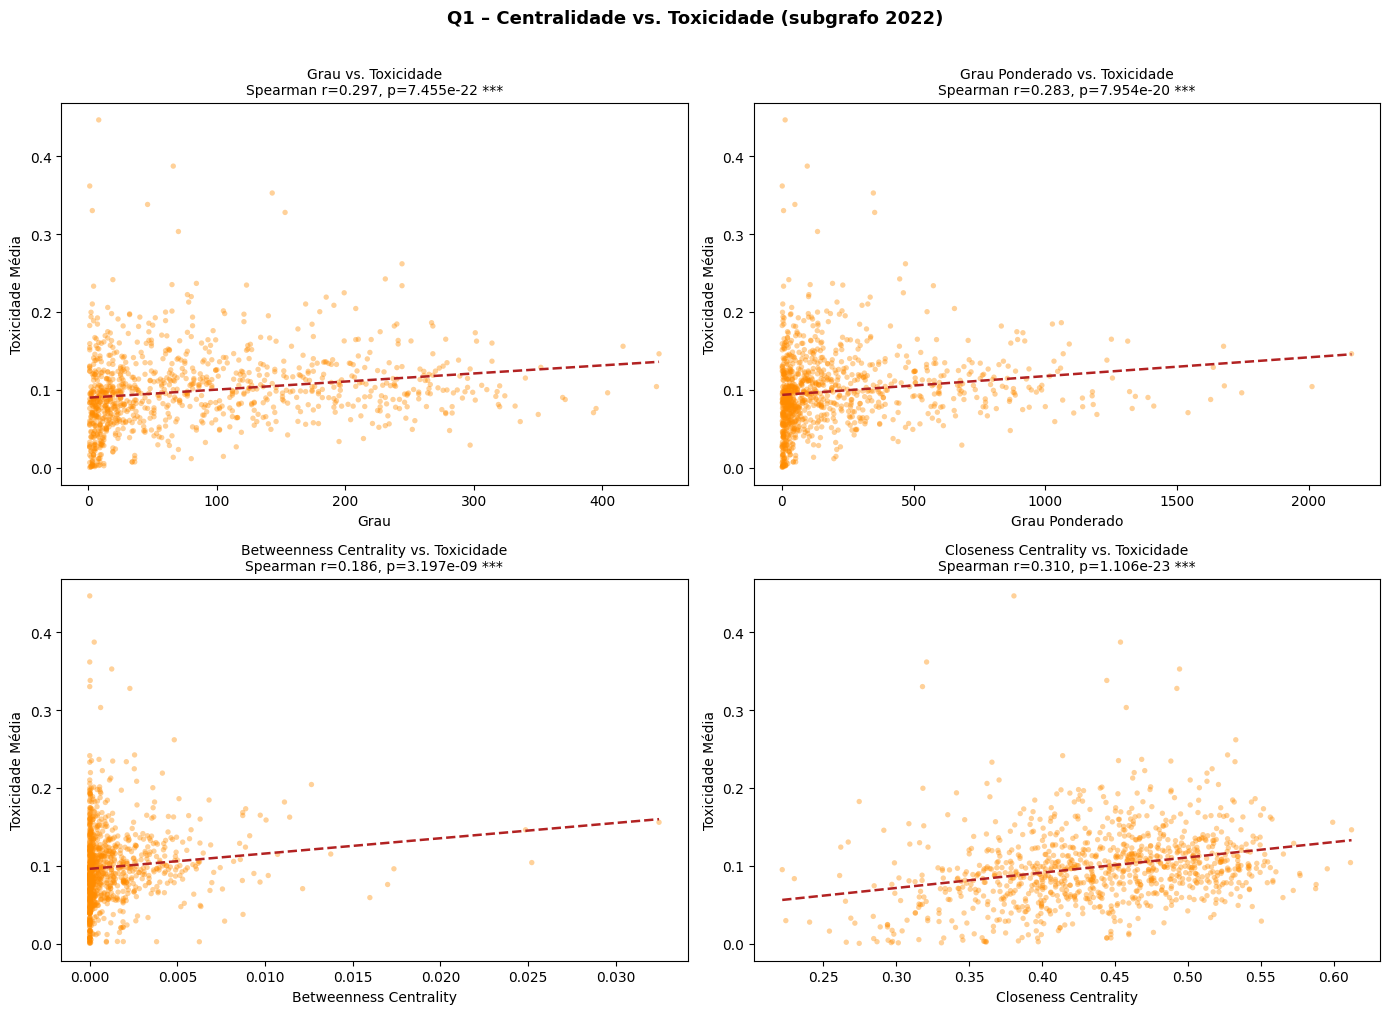


── Resultados Q1 ──
Grau                            r=+0.2971  p=7.4554e-22  ***
Grau Ponderado                  r=+0.2825  p=7.9541e-20  ***
Betweenness Centrality          r=+0.1858  p=3.1966e-09  ***
Closeness Centrality            r=+0.3096  p=1.1061e-23  ***


In [ ]:
df_maior = df[df['no_maior_comp']].dropna(subset=['betweenness', 'closeness'])

metricas = [
    ('grau','Grau'),
    ('grau_ponderado','Grau Ponderado'),
    ('betweenness','Betweenness Centrality'),
    ('closeness','Closeness Centrality'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
resultados_q1 = {}

for ax, (col, label) in zip(axes, metricas):
    dados = df_maior[[col, 'toxicity']].dropna()
    r, p = scipy_stats.spearmanr(dados[col], dados['toxicity'])
    resultados_q1[label] = {'r': r, 'p': p}

    ax.scatter(dados[col], dados['toxicity'],alpha=0.4, s=15, color='darkorange', edgecolors='none')
    m, b = np.polyfit(dados[col], dados['toxicity'], 1)
    xseq = np.linspace(dados[col].min(), dados[col].max(), 100)
    ax.plot(xseq, m * xseq + b, color='firebrick', linewidth=1.8, linestyle='--')

    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    ax.set_xlabel(label)
    ax.set_ylabel('Toxicidade Média')
    ax.set_title(f'{label} vs. Toxicidade\nSpearman r={r:.3f}, p={p:.3e} {sig}', fontsize=10)

plt.suptitle('Q1 – Centralidade vs. Toxicidade (subgrafo 2022)',fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('q1_centralidade_toxicidade.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── Resultados Q1 ──')
for met, res in resultados_q1.items():
    sig = '***' if res['p'] < 0.001 else ('**' if res['p'] < 0.01 else ('*' if res['p'] < 0.05 else 'n.s.'))
    print(f'{met:30s}  r={res["r"]:+.4f}  p={res["p"]:.4e}  {sig}')

In [ ]:
# Top 20 grupos mais centrais e seus escores de toxicidade
top_central = (df_maior.nlargest(20, 'betweenness')[['group_name', 'betweenness', 'grau', 'toxicity', 'insult', 'threat']].reset_index(drop=True).round(4))
top_central.columns = ['Grupo', 'Betweenness', 'Grau', 'Toxicidade', 'Insulto', 'Ameaça']
print('Top 20 grupos mais centrais (betweenness) — 2022:')
print(top_central.to_string(index=False))
top_central.to_csv('q1_top_centrais_2022.csv', index=False)

Top 20 grupos mais centrais (betweenness) — 2022:
                      Grupo  Betweenness  Grau  Toxicidade  Insulto  Ameaça
LNB - 🇺🇦 Apoio à Ucrânia 🇺🇦       0.0325   416      0.1559   0.0677  0.0089
  DIREITA CONTRA A ESQUERDA       0.0252   442      0.1042   0.0500  0.0032
  Política direita esquerda       0.0249   444      0.1463   0.0641  0.0088
     Debate  político  2022       0.0173   404      0.0962   0.0421  0.0048
       Reconstruindo o Br 3       0.0170   395      0.0760   0.0347  0.0033
   📰𝕯𝖎𝖆́𝖗𝖎𝖔👁️‍🗨️𝕭𝖗𝖆𝖘𝖎𝖑𝖊𝖎𝖗𝖔🔰       0.0160   336      0.0592   0.0312  0.0019
  1 - SÓ LINKS DE (DIREITA)       0.0137   340      0.1151   0.0552  0.0037
            LULA PRESIDENTE       0.0126   208      0.2044   0.0942  0.0088
    OS PATRIOTAS.......🟢🟡🟨🟩       0.0121   393      0.0707   0.0334  0.0032
    Em Defesa da Democracia       0.0114   302      0.1625   0.0772  0.0039
      NEFERTITE NA POLÍTICA       0.0111   268      0.1819   0.0776  0.0129
PATRIOTAS COM🇧🇷 BOLSONARO🇧🇷       0.01

---
## Q2 — A toxicidade está concentrada ou distribuída uniformemente?

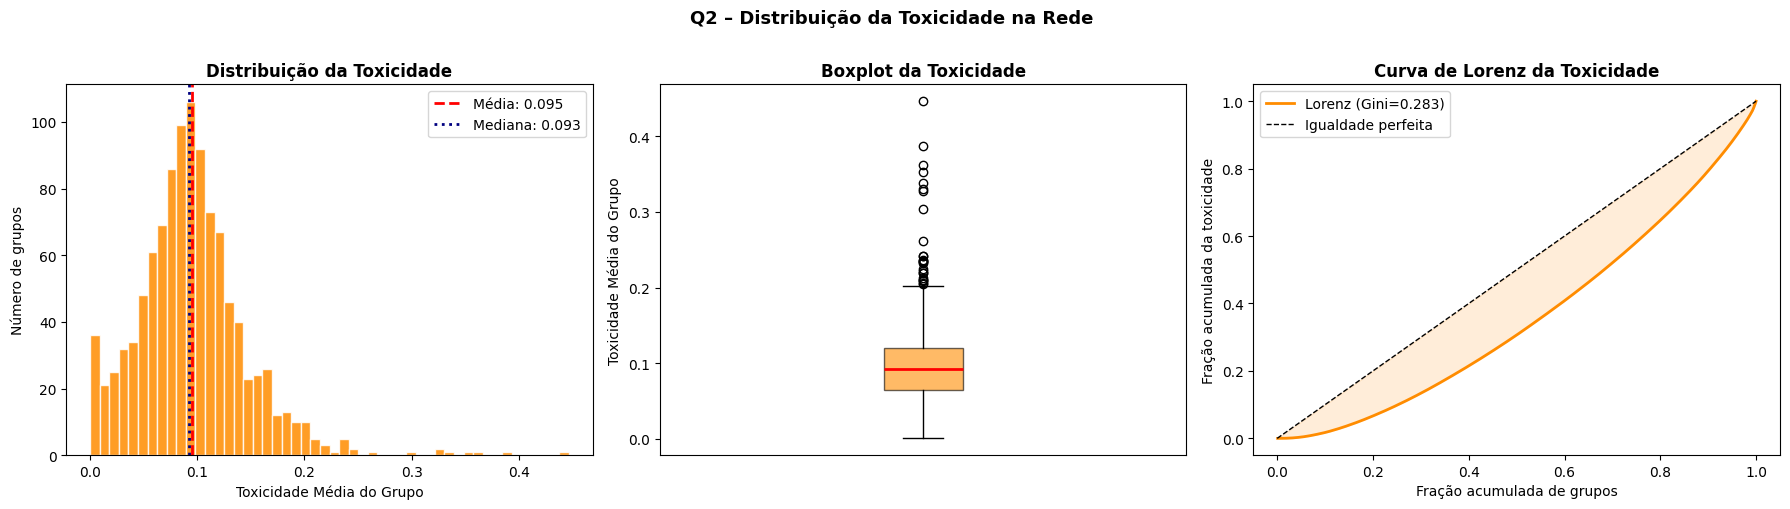


── Estatísticas Q2 ──
Média:             0.0955
Mediana:           0.0928
Desvio padrão:     0.0510
Coef. de Gini:     0.2835
Grupos tox > 0.3:  0.7%
Grupos tox > 0.5:  0.0%


In [ ]:
tox = df['toxicity'].dropna().values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
axes[0].hist(tox, bins=50, color='darkorange', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(tox), color='red', linestyle='--', lw=2, label=f'Média: {np.mean(tox):.3f}')
axes[0].axvline(np.median(tox), color='navy', linestyle=':',  lw=2, label=f'Mediana: {np.median(tox):.3f}')
axes[0].set_xlabel('Toxicidade Média do Grupo')
axes[0].set_ylabel('Número de grupos')
axes[0].set_title('Distribuição da Toxicidade', fontweight='bold')
axes[0].legend()

# Boxplot
axes[1].boxplot(tox, patch_artist=True,boxprops=dict(facecolor='darkorange', alpha=0.6),medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Toxicidade Média do Grupo')
axes[1].set_title('Boxplot da Toxicidade', fontweight='bold')
axes[1].set_xticks([])

# Curva de Lorenz
tox_sorted = np.sort(tox)
cumsum = np.cumsum(tox_sorted) / tox_sorted.sum()
cumfrac = np.arange(1, len(tox_sorted) + 1) / len(tox_sorted)
gini = 1 - 2 * np.trapezoid(cumsum, cumfrac)

axes[2].plot(cumfrac, cumsum, color='darkorange', lw=2, label=f'Lorenz (Gini={gini:.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', lw=1, label='Igualdade perfeita')
axes[2].fill_between(cumfrac, cumfrac, cumsum, alpha=0.15, color='darkorange')
axes[2].set_xlabel('Fração acumulada de grupos')
axes[2].set_ylabel('Fração acumulada da toxicidade')
axes[2].set_title('Curva de Lorenz da Toxicidade', fontweight='bold')
axes[2].legend()

plt.suptitle('Q2 – Distribuição da Toxicidade na Rede ',fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('q2_distribuicao_toxicidade.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n── Estatísticas Q2 ──')
print(f'Média:             {np.mean(tox):.4f}')
print(f'Mediana:           {np.median(tox):.4f}')
print(f'Desvio padrão:     {np.std(tox):.4f}')
print(f'Coef. de Gini:     {gini:.4f}')
pct_03 = (tox > 0.3).mean() * 100
pct_05 = (tox > 0.5).mean() * 100
print(f'Grupos tox > 0.3:  {pct_03:.1f}%')
print(f'Grupos tox > 0.5:  {pct_05:.1f}%')

In [ ]:
# Top 20 grupos mais tóxicos de 2022
top_toxicos = (df.nlargest(20, 'toxicity')[['group_name', 'toxicity', 'severe_toxicity', 'insult', 'threat', 'grau', 'n_msgs']].reset_index(drop=True).round(4))
top_toxicos.columns = ['Grupo', 'Toxicidade', 'Tox. Severa', 'Insulto', 'Ameaça', 'Grau', 'N Msgs']
print('Top 20 grupos mais tóxicos:')
print(top_toxicos.to_string(index=False))
top_toxicos.to_csv('q2_top_toxicos_2022.csv', index=False)

Top 20 grupos mais tóxicos:
                   Grupo  Toxicidade  Tox. Severa  Insulto  Ameaça  Grau  N Msgs
        🦅Direita Raiz!🇧🇷      0.4466       0.0032   0.1630  0.0027     8     500
  🦅JUSTIÇA DE VERDADE 🇺🇸      0.3873       0.0029   0.1445  0.0035    66     500
            SAPO FUMANTE      0.3617       0.0059   0.1323  0.0024     1      10
        Brasil imparcial      0.3527       0.0031   0.1318  0.0075   143     500
  Bolsonaro Herói do Clã      0.3380       0.0021   0.2167  0.0020    46      53
     DIREITA DE VERDADE.      0.3301       0.0020   0.1808  0.0057     3     126
 Boisonaro Genocida 💩🖕🏻🤾      0.3278       0.0011   0.2389  0.0057   153     500
       ༒☬USTRA VIVE #6☬༒      0.3033       0.0021   0.1295  0.0024    70     500
     Conservadores BR ➡️      0.2618       0.0026   0.1045  0.0081   244     500
      POLITICA NEFASTA 2      0.2424       0.0028   0.0893  0.0043   231     500
        Brasil em Debate      0.2415       0.0011   0.1382  0.0045    19     126


---
## Q3 — Existem comunidades com padrões de toxicidade distintos?

In [28]:
print('Detectando comunidades com Louvain (subgrafo 2022)...')
try:
    from networkx.algorithms.community import louvain_communities
    comunidades = louvain_communities(G_maior_22, seed=RANDOM_SEED, weight='weight')
except ImportError:
    from networkx.algorithms.community import greedy_modularity_communities
    comunidades = list(greedy_modularity_communities(G_maior_22, weight='weight'))

modularidade = nx.algorithms.community.modularity(G_maior_22, comunidades, weight='weight')
print(f'Comunidades detectadas: {len(comunidades):,}')
print(f'Modularidade: {modularidade:.4f}')

comunidade_dict = {}
for cid, comm in enumerate(comunidades):
    for node in comm:
        comunidade_dict[node] = cid

df['comunidade'] = df['group_id'].map(comunidade_dict)

stats_comm = (df
    .dropna(subset=['comunidade', 'toxicity'])
    .groupby('comunidade')
    .agg(
        n_grupos = ('group_id', 'count'),
        tox_media = ('toxicity', 'mean'),
        tox_mediana = ('toxicity', 'median'),
        tox_std = ('toxicity', 'std'),
        insult_media = ('insult', 'mean'),
        threat_media = ('threat', 'mean'),
        grau_medio = ('grau', 'mean'),
    )
    .query('n_grupos >= 5')
    .sort_values('tox_media', ascending=False)
    .reset_index()
)
print(f'\nComunidades com >= 5 grupos: {len(stats_comm)}')
print(stats_comm.round(4).to_string(index=False))

Detectando comunidades com Louvain (subgrafo 2022)...
Comunidades detectadas: 22
Modularidade: 0.3345

Comunidades com >= 5 grupos: 14
 comunidade  n_grupos  tox_media  tox_mediana  tox_std  insult_media  threat_media  grau_medio
       21.0       104     0.1197       0.1115   0.0515        0.0534        0.0066     55.8654
        6.0       341     0.1065       0.1003   0.0462        0.0545        0.0042    112.7273
       10.0       226     0.1057       0.1005   0.0547        0.0514        0.0044    116.4867
        8.0        10     0.0999       0.0878   0.0466        0.0353        0.0038     33.4000
       14.0       113     0.0968       0.0899   0.0470        0.0477        0.0044     67.0265
       20.0        19     0.0910       0.0796   0.0329        0.0459        0.0063     16.2632
       18.0        10     0.0906       0.0825   0.0369        0.0447        0.0063     12.1000
        1.0         5     0.0778       0.0816   0.0493        0.0262        0.0029      4.4000
        5.

In [30]:
import pandas as pd

# nós da comunidade 21
nos_c21 = [n for n in G_maior_22.nodes() if comunidade_dict.get(n) == 21]

# toxicidade dos nós da comunidade
tox_c21 = {
    n: cache[n]['toxicity']
    for n in nos_c21
    if n in cache
}

# nomes dos grupos
nome_c21 = dict(zip(df['group_id'], df['group_name']))

# top 10
top10 = sorted(
    tox_c21.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

# dataframe
df_top10 = pd.DataFrame(
    [
        {
            'Grupo': nome_c21.get(gid, gid),
            'Toxicidade': round(tox, 4)
        }
        for gid, tox in top10
    ]
)

print(df_top10.to_string(index=False))

                     Grupo  Toxicidade
   Boisonaro Genocida 💩🖕🏻🤾      0.3278
                     VEGAS      0.2367
   Bolsonaro presidente 🇧🇷      0.2127
           LULA PRESIDENTE      0.2044
           𝔼𝕝𝕖𝕚𝕔𝕠𝕖𝕤 2022🖊️      0.2014
              Brasil Livre      0.2011
          ELEIÇÕES 2022 🇧🇷      0.2003
               Lula ladrão      0.1998
             Direita Unida      0.1996
7-🔰INTERVENÇÃO🇧🇷BOLSONARO🔰      0.1979


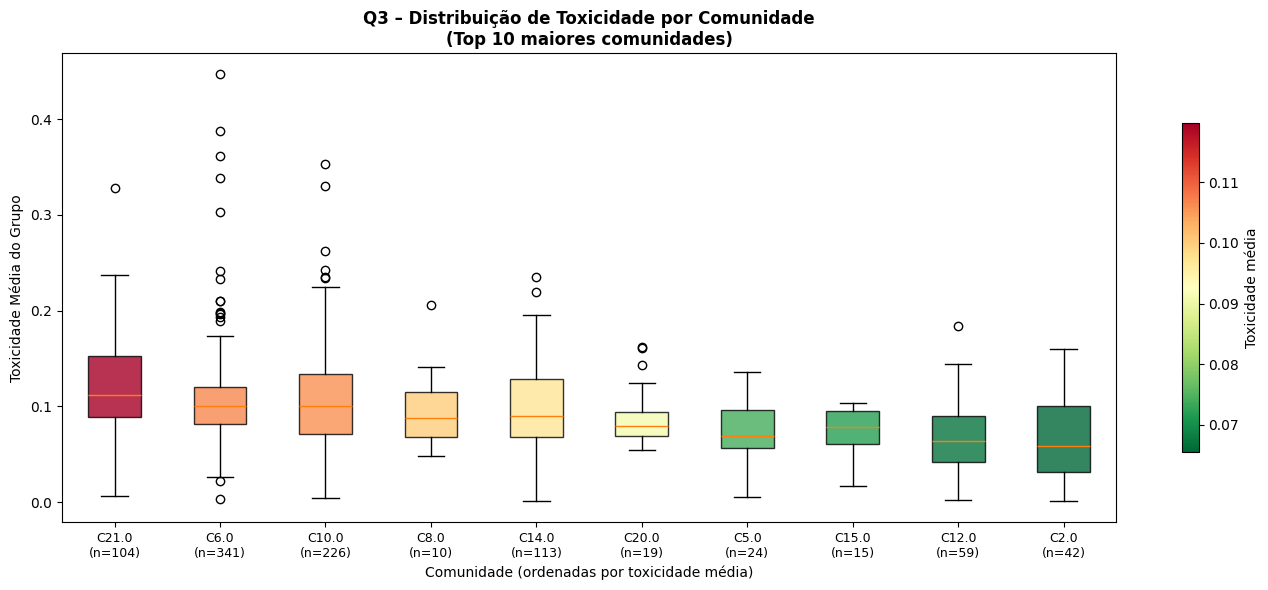


Kruskal-Wallis: H=97.772, p=4.4378e-17
*** Diferenças significativas entre comunidades


In [ ]:
# Boxplot de toxicidade por comunidade (top 10 maiores)
top_comms = stats_comm.nlargest(10, 'n_grupos')['comunidade'].tolist()
df_plot = df[df['comunidade'].isin(top_comms)].dropna(subset=['toxicity'])
ordem = (df_plot.groupby('comunidade')['toxicity'].mean().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(14, 6))
dados_bp = [df_plot[df_plot['comunidade'] == c]['toxicity'].values for c in ordem]
bp = ax.boxplot(dados_bp, patch_artist=True)

cmap = plt.get_cmap('RdYlGn_r')
medias = [np.mean(d) for d in dados_bp]
norm = mcolors.Normalize(vmin=min(medias), vmax=max(medias))
for patch, media in zip(bp['boxes'], medias):
    patch.set_facecolor(cmap(norm(media)))
    patch.set_alpha(0.8)

ax.set_xticklabels([f'C{c}\n(n={len(df_plot[df_plot["comunidade"]==c])})' for c in ordem],fontsize=9)
ax.set_xlabel('Comunidade (ordenadas por toxicidade média)')
ax.set_ylabel('Toxicidade Média do Grupo')
ax.set_title('Q3 – Distribuição de Toxicidade por Comunidade\n(Top 10 maiores comunidades)',fontweight='bold')

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Toxicidade média', shrink=0.7)
plt.tight_layout()
plt.savefig('q3_toxicidade_comunidades.png', dpi=150, bbox_inches='tight')
plt.show()

# Kruskal-Wallis
H, p_kw = scipy_stats.kruskal(*dados_bp)
print(f'\nKruskal-Wallis: H={H:.3f}, p={p_kw:.4e}')
print('*** Diferenças significativas entre comunidades' if p_kw < 0.001 else 'n.s.')

---
## Q4 — Há homofilia de toxicidade na rede?

In [ ]:
# Construir subgrafo só com nós que têm toxicidade
G_tox = G_2022.copy()

# Adicionar atributo de toxicidade diretamente do dicionário escores_2022
for gid, e in escores_2022.items():
    if G_tox.has_node(gid):
        G_tox.nodes[gid]['toxicity'] = e['toxicity']

# Remover nós sem toxicidade
nos_sem_tox = [n for n in G_tox.nodes() if 'toxicity' not in G_tox.nodes[n]]
G_tox.remove_nodes_from(nos_sem_tox)
print(f'Nós com toxicidade: {G_tox.number_of_nodes():,}')
print(f'Nós removidos (sem toxicidade): {len(nos_sem_tox):,}')

# Assortativity
try:
    r_assort = nx.numeric_assortativity_coefficient(G_tox, 'toxicity')
    print(f'Assortativity numérico: r = {r_assort:.4f}')
except Exception as e:
    print(f'Erro assortativity: {e}')
    r_assort = np.nan

# Correlação nó vs. média dos vizinhos
tox_no, tox_viz = [], []
for n in G_tox.nodes():
    vizinhos = [G_tox.nodes[v]['toxicity'] for v in G_tox.neighbors(n)
                if 'toxicity' in G_tox.nodes[v]]
    if vizinhos:
        tox_no.append(G_tox.nodes[n]['toxicity'])
        tox_viz.append(np.mean(vizinhos))

tox_no  = np.array(tox_no)
tox_viz = np.array(tox_viz)
print(f'Pares nó-vizinho para correlação: {len(tox_no):,}')

r_sp, p_sp = scipy_stats.spearmanr(tox_no, tox_viz)
if len(tox_no) >= 2:
    r_pe, p_pe = scipy_stats.pearsonr(tox_no, tox_viz)
else:
    r_pe, p_pe = np.nan, np.nan

print(f'Spearman (nó vs. vizinhos): r={r_sp:.4f}, p={p_sp:.4e}')
print(f'Pearson  (nó vs. vizinhos): r={r_pe:.4f}, p={p_pe:.4e}')

Nós com toxicidade: 1,078
Nós removidos (sem toxicidade): 144
Assortativity numérico: r = 0.0735
Pares nó-vizinho para correlação: 1,021
Spearman (nó vs. vizinhos): r=0.4345, p=2.8753e-48
Pearson  (nó vs. vizinhos): r=0.4251, p=4.5276e-46


---
## Visualização Final — Rede 2022 colorida por Toxicidade

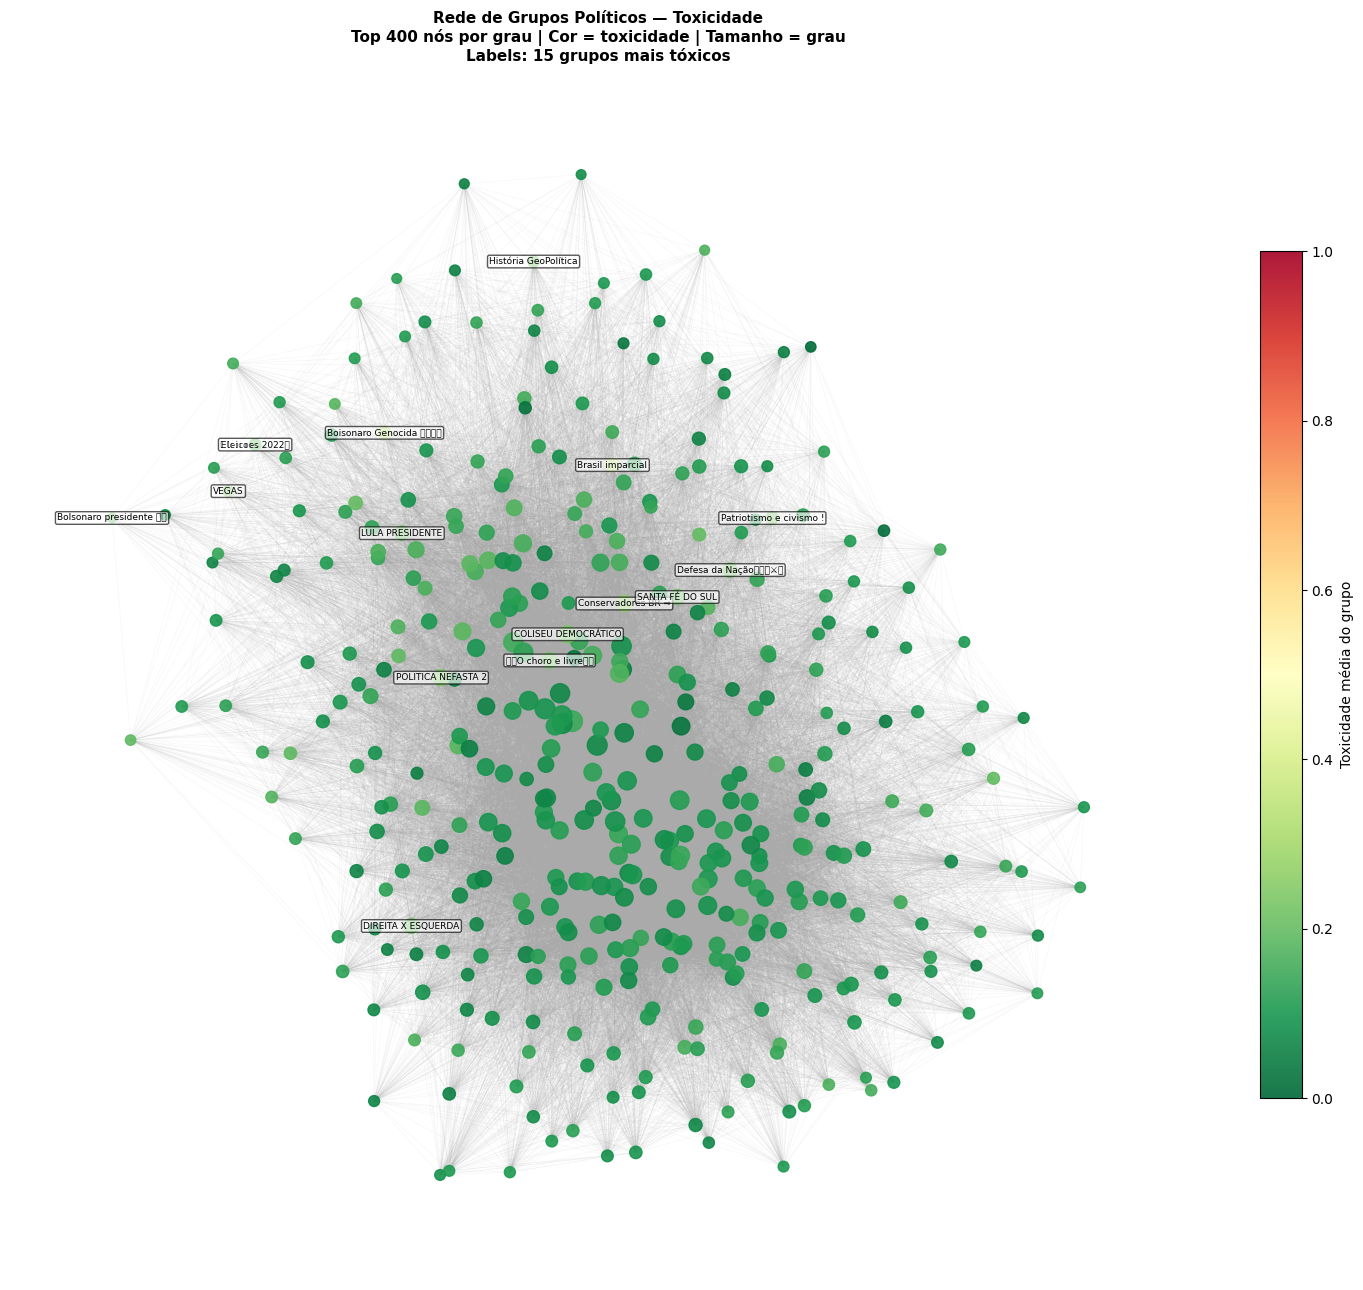

Salvo: rede_toxicidade_2022.png


In [ ]:
def visualizar_rede_toxicidade(G, escores, max_nos=400):
    nos_maior = max(nx.connected_components(G), key=len)
    G_maior = G.subgraph(nos_maior).copy()

    # Adicionar toxicidade como atributo
    for n in G_maior.nodes():
        G_maior.nodes[n]['toxicity'] = escores.get(n, {}).get('toxicity', np.nan)

    nos_com_tox = [n for n in G_maior.nodes()
                   if not np.isnan(G_maior.nodes[n].get('toxicity', np.nan))]
    G_sub = G_maior.subgraph(nos_com_tox).copy()

    if G_sub.number_of_nodes() > max_nos:
        top = sorted(G_sub.degree(), key=lambda x: x[1], reverse=True)[:max_nos]
        G_vis = G_sub.subgraph([n for n, _ in top]).copy()
    else:
        G_vis = G_sub

    graus = dict(G_vis.degree())
    tox_vals = [G_vis.nodes[n]['toxicity'] for n in G_vis.nodes()]
    max_g = max(graus.values()) or 1
    sizes = [20 + 200 * (graus[n] / max_g) for n in G_vis.nodes()]

    pos = nx.spring_layout(G_vis, seed=RANDOM_SEED,k=1.3 / (G_vis.number_of_nodes() ** 0.5))

    fig, ax = plt.subplots(figsize=(15, 13))
    nx.draw_networkx_edges(G_vis, pos, ax=ax, alpha=0.12, width=0.4, edge_color='#aaa')
    sc = nx.draw_networkx_nodes(G_vis, pos, ax=ax,node_size=sizes, node_color=tox_vals,cmap='RdYlGn_r', vmin=0, vmax=1, alpha=0.9)
    plt.colorbar(sc, ax=ax, label='Toxicidade média do grupo', shrink=0.7)

    # Labels: top 15 mais tóxicos
    top15 = sorted([(n, G_vis.nodes[n]['toxicity']) for n in G_vis.nodes()],key=lambda x: x[1], reverse=True)[:15]
    labels = {}
    for n, _ in top15:
        nome = G_vis.nodes[n].get('name', str(n))
        labels[n] = nome[:25] + ('…' if len(nome) > 25 else '')

    nx.draw_networkx_labels(G_vis, pos, labels=labels, ax=ax,font_size=6.5, font_color='black',bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.65))

    ax.set_title(
        f'Rede de Grupos Políticos — Toxicidade\n'
        f'Top {G_vis.number_of_nodes()} nós por grau | Cor = toxicidade | Tamanho = grau\n'
        f'Labels: 15 grupos mais tóxicos',
        fontsize=11, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('rede_toxicidade_2022.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Salvo: rede_toxicidade_2022.png')


visualizar_rede_toxicidade(G_2022, escores_2022, max_nos=400)

Nós: 400 -> 400 (após remover isolados)
Arestas: 30588 -> 9786 (filtro percentil 70)


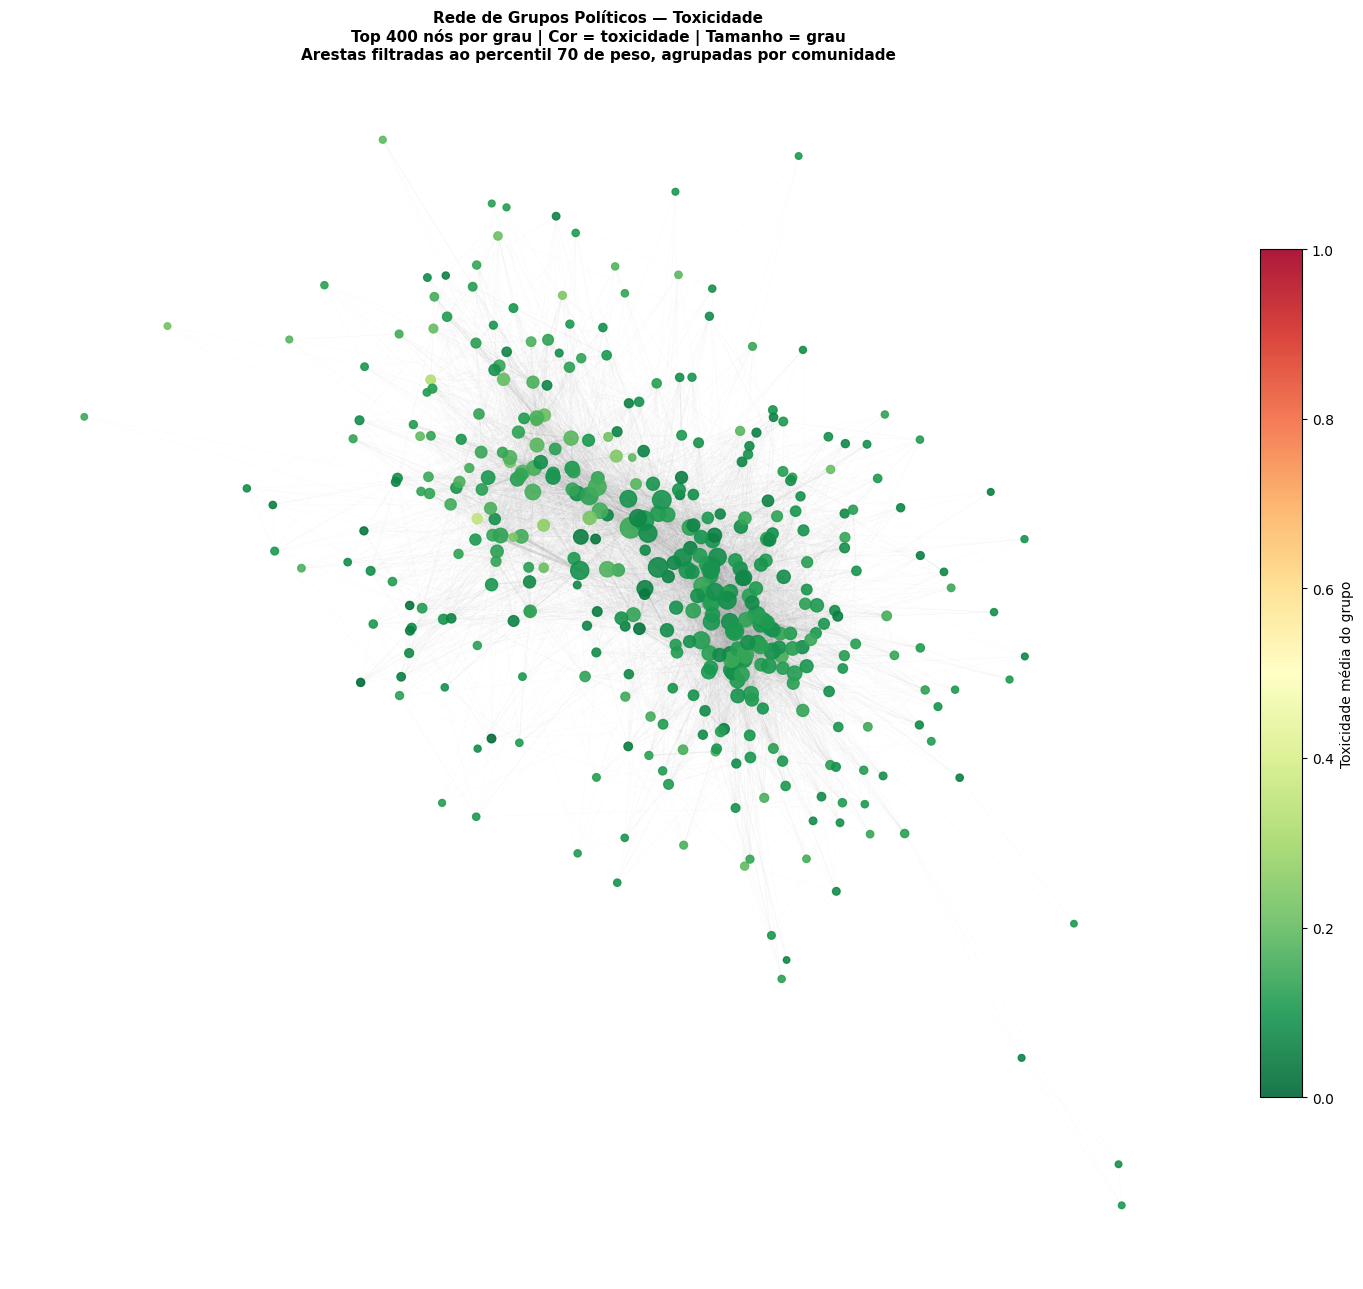

Salvo: rede_toxicidade_2022.png


In [20]:
def visualizar_rede_toxicidade(G, escores, max_nos=400, percentil_peso=70):
    nos_maior = max(nx.connected_components(G), key=len)
    G_maior = G.subgraph(nos_maior).copy()

    # Adicionar toxicidade como atributo
    for n in G_maior.nodes():
        G_maior.nodes[n]['toxicity'] = escores.get(n, {}).get('toxicity', np.nan)

    nos_com_tox = [n for n in G_maior.nodes()
                   if not np.isnan(G_maior.nodes[n].get('toxicity', np.nan))]
    G_sub = G_maior.subgraph(nos_com_tox).copy()

    if G_sub.number_of_nodes() > max_nos:
        top = sorted(G_sub.degree(), key=lambda x: x[1], reverse=True)[:max_nos]
        G_vis = G_sub.subgraph([n for n, _ in top]).copy()
    else:
        G_vis = G_sub

    # --- filtro de arestas fracas por percentil de peso ---
    pesos = [d.get('weight', 1) for _, _, d in G_vis.edges(data=True)]
    limiar = np.percentile(pesos, percentil_peso)
    arestas_fortes = [(u, v, d) for u, v, d in G_vis.edges(data=True)
                       if d.get('weight', 1) >= limiar]

    G_filtrado = nx.Graph()
    G_filtrado.add_nodes_from(G_vis.nodes(data=True))
    G_filtrado.add_edges_from(arestas_fortes)
    G_filtrado.remove_nodes_from(list(nx.isolates(G_filtrado)))  # tira nós que ficaram soltos

    print(f'Nós: {G_vis.number_of_nodes()} -> {G_filtrado.number_of_nodes()} (após remover isolados)')
    print(f'Arestas: {G_vis.number_of_edges()} -> {G_filtrado.number_of_edges()} (filtro percentil {percentil_peso})')

    graus = dict(G_filtrado.degree())
    tox_vals = [G_filtrado.nodes[n]['toxicity'] for n in G_filtrado.nodes()]
    max_g = max(graus.values()) or 1
    sizes = [20 + 200 * (graus[n] / max_g) for n in G_filtrado.nodes()]

    # --- layout agrupado por comunidade ---
    particao = community_louvain.best_partition(G_filtrado, weight='weight')
    comunidades_unicas = set(particao.values())
    n_com = len(comunidades_unicas)
    angulo = {c: 2 * np.pi * i / n_com for i, c in enumerate(comunidades_unicas)}
    raio_comunidade = 3.0

    pos_inicial = {}
    for n, com in particao.items():
        cx = raio_comunidade * np.cos(angulo[com])
        cy = raio_comunidade * np.sin(angulo[com])
        pos_inicial[n] = (cx + np.random.uniform(-0.5, 0.5),
                          cy + np.random.uniform(-0.5, 0.5))

    pos = nx.spring_layout(
        G_filtrado, pos=pos_inicial, weight='weight',
        seed=RANDOM_SEED, k=1.3 / (G_filtrado.number_of_nodes() ** 0.5),
        iterations=100
    )

    fig, ax = plt.subplots(figsize=(15, 13))

    # arestas com espessura/transparência proporcional ao peso
    max_peso = max(d.get('weight', 1) for _, _, d in G_filtrado.edges(data=True))
    for u, v, d in G_filtrado.edges(data=True):
        peso_norm = d.get('weight', 1) / max_peso
        nx.draw_networkx_edges(
            G_filtrado, pos, edgelist=[(u, v)], ax=ax,
            alpha=min(0.05 + peso_norm * 0.4, 0.5),
            width=0.3 + peso_norm * 2, edge_color='#aaa'
        )

    sc = nx.draw_networkx_nodes(
        G_filtrado, pos, ax=ax, node_size=sizes, node_color=tox_vals,
        cmap='RdYlGn_r', vmin=0, vmax=1, alpha=0.9
    )
    plt.colorbar(sc, ax=ax, label='Toxicidade média do grupo', shrink=0.7)

    ax.set_title(
        f'Rede de Grupos Políticos — Toxicidade\n'
        f'Top {G_filtrado.number_of_nodes()} nós por grau | Cor = toxicidade | Tamanho = grau\n'
        f'Arestas filtradas ao percentil {percentil_peso} de peso, agrupadas por comunidade',
        fontsize=11, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('rede_toxicidade_2022.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Salvo: rede_toxicidade_2022.png')

visualizar_rede_toxicidade(G_2022, escores_2022, max_nos=400, percentil_peso=70)

In [23]:
pesos = [d["weight"] for _, _, d in G_2022.edges(data=True)]
print(pd.Series(pesos).describe())

count    43376.000000
mean         2.569762
std          4.266113
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        164.000000
dtype: float64


In [24]:
for t in [2,3,5,10,15,20]:
    n = sum(d["weight"] >= t for _,_,d in G_2022.edges(data=True))
    print(f"Peso ≥ {t}: {n} arestas")

Peso ≥ 2: 20955 arestas
Peso ≥ 3: 11252 arestas
Peso ≥ 5: 5025 arestas
Peso ≥ 10: 1394 arestas
Peso ≥ 15: 655 arestas
Peso ≥ 20: 340 arestas


Uma coisa que pequei e não analisei antes, era quantas conexões "fracas" nos tinhamos que estava deixando a rede mais poluida.

In [ ]:
def exportar_para_gephi(G, particao_louvain, escores, caminho_saida='rede_2022.gexf'):
    """
    Exporta o subgrafo (maior componente, 2022) para GEXF, com atributos de
    comunidade (Louvain) e toxicidade média.
    """
    G_export = G.copy()

    faltando_comunidade = 0
    faltando_toxicidade = 0

    for n in G_export.nodes():
        com = particao_louvain.get(n)
        if com is None:
            faltando_comunidade += 1
            com = -1
        G_export.nodes[n]['community'] = int(com)

        tox = escores.get(n, {}).get('toxicity', None)
        if tox is None or (isinstance(tox, float) and np.isnan(tox)):
            faltando_toxicidade += 1
            tox = 0.0
        G_export.nodes[n]['toxicidade_media'] = float(tox)

        nome = G_export.nodes[n].get('name', str(n))
        G_export.nodes[n]['label'] = nome
        G_export.nodes[n]['grau'] = int(G_export.degree(n))

    print(f'Nós exportados: {G_export.number_of_nodes():,}')
    print(f'Arestas exportadas: {G_export.number_of_edges():,}')
    print(f'Nós sem comunidade atribuída (viraram -1): {faltando_comunidade}')
    print(f'Nós sem toxicidade calculada (viraram 0.0): {faltando_toxicidade}')

    nx.write_gexf(G_export, caminho_saida)
    print(f'Salvo em: {caminho_saida}')

    return G_export


G_gephi = exportar_para_gephi(G_maior_22, particao_2022, escores_2022, 'rede_2022.gexf')

Nós exportados: 1,053
Arestas exportadas: 43,258
Nós sem comunidade atribuída (viraram -1): 0
Nós sem toxicidade calculada (viraram 0.0): 52
Salvo em: rede_2022.gexf


---
## Resumo Geral dos Resultados

In [ ]:
print('=' * 60)
print('RESUMO — PROJETO FINAL')
print('=' * 60)

print(f'\n[Rede Completa 2020–2024]')
print(f'  Grupos:          {G_completo.number_of_nodes():,}')
print(f'  Arestas:         {G_completo.number_of_edges():,}')
print(f'  Maior comp.:     {len(nos_maior_c):,} nós ({100*len(nos_maior_c)/G_completo.number_of_nodes():.1f}%)')
print(f'  Clustering médio:{cc_medio_c:.4f}')

print(f'\n[Subgrafo 2022]')
print(f'  Grupos:          {G_2022.number_of_nodes():,}')
print(f'  Arestas:         {G_2022.number_of_edges():,}')
print(f'  Maior comp.:     {len(nos_maior_22):,} nós ({100*len(nos_maior_22)/G_2022.number_of_nodes():.1f}%)')
print(f'  Clustering médio:{cc_medio_22:.4f}')

print(f'\n[Q1] Centralidade vs. Toxicidade')
for met, res in resultados_q1.items():
    sig = '(sig.)' if res['p'] < 0.05 else '(n.s.)'
    print(f'  {met:30s} r={res["r"]:+.3f} {sig}')

print(f'\n[Q2] Distribuição')
print(f'  Média: {np.mean(tox):.3f} | Mediana: {np.median(tox):.3f} | Gini: {gini:.3f}')
print(f'  Grupos com tox > 0.3: {pct_03:.1f}% | > 0.5: {pct_05:.1f}%')

print(f'\n[Q3] Comunidades')
print(f'  Comunidades: {len(comunidades):,} | Modularidade: {modularidade:.4f}')
print(f'  Kruskal-Wallis: H={H:.2f}, p={p_kw:.4e}')

print(f'\n[Q4] Homofilia')
print(f'  Assortativity: r={r_assort:.4f}')
print(f'  Spearman (nó vs. vizinhos): r={r_sp:.4f}, p={p_sp:.4e}')
print('=' * 60)

RESUMO — PROJETO FINAL

[Rede Completa 2020–2024]
  Grupos:          2,109
  Arestas:         89,421
  Maior comp.:     1,860 nós (88.2%)
  Clustering médio:0.5568

[Subgrafo 2022]
  Grupos:          1,222
  Arestas:         43,376
  Maior comp.:     1,053 nós (86.2%)
  Clustering médio:0.4848

[Q1] Centralidade vs. Toxicidade
  Grau                           r=+0.297 (sig.)
  Grau Ponderado                 r=+0.283 (sig.)
  Betweenness Centrality         r=+0.186 (sig.)
  Closeness Centrality           r=+0.310 (sig.)

[Q2] Distribuição
  Média: 0.095 | Mediana: 0.093 | Gini: 0.283
  Grupos com tox > 0.3: 0.7% | > 0.5: 0.0%

[Q3] Comunidades
  Comunidades: 22 | Modularidade: 0.3345
  Kruskal-Wallis: H=97.77, p=4.4378e-17

[Q4] Homofilia
  Assortativity: r=0.0735
  Spearman (nó vs. vizinhos): r=0.4345, p=2.8753e-48


# Parte 3 — Análise Estratificada de Toxicidade (Limiar Severo $\ge$ 0.7)

Para mitigar ruídos causados por falsos positivos na classificação do Detoxify e focar exclusivamente no comportamento de ambientes altamente hostis ou radicalizados, esta seção adota um ponto de corte empírico de **0.7**. 

A variável de toxicidade deixa de ser avaliada de forma puramente contínua e passa a ser tratada como um estrato categórico binário:
- **Altamente Tóxico:** Grupos com score $\ge 0.7$
- **Baixo / Normal:** Grupos com score $< 0.7$

Abaixo, revisitamos as 4 Questões de Pesquisa sob esta ótica estratificada.